In [114]:
%pip install torch torchvision matplotlib torchmetrics lightning

  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 13.9 MB/s  0:00:00
Using cached attrs-26.1.0-py3-none-any.whl (67 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 11.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [lightning]37m━━━ 11/12 [lightning]]
Note: you may need to restart the kernel to use updated packages.


In [89]:
import torch

## Tensors

In [90]:
# Tensors
vector_data = [0.0, 1.0, 2.0]
matrix_data = [[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]]

# tensor is central data abstraction for building nn in Pytorch
vector = torch.Tensor(vector_data) 
matrix = torch.Tensor(matrix_data)
print("Vector:", vector)
print("Matrix:", matrix)

# create tensors of random numbers from std norm dist ~N(0, 1)
X = torch.randn((2,2))
y = torch.randn((2))
print("X:", X)
print("y:", y)

# tensor of some shape of all zeros
bias = torch.zeros((3, 1, 3), dtype=torch.int64)
print("Bias:", bias)

Vector: tensor([0., 1., 2.])
Matrix: tensor([[1., 0., 0.],
        [0., 1., 0.]])
X: tensor([[ 0.1061,  0.9241],
        [-0.5996, -0.1344]])
y: tensor([-0.5840,  0.1197])
Bias: tensor([[[0, 0, 0]],

        [[0, 0, 0]],

        [[0, 0, 0]]])


### Tensor Operations

In [91]:
# operations: 
# +, -, * (dot product), y, /, @ (mat-mul)
z = X / y
z2 = X @ y
print(z)
print(z2)
print(z.shape)

# indexing
x = torch.randn((2,3))
print("x:", x)
print("x[0]:", x[0])

# concatenation
xx = torch.cat((x,x))
print("xx:", xx)

# view creates a new tensor object that shares same memory as original
# -1 flattens a multidimensional tensor
t = x.view(-1)
print("t:", t)
x[:, 1] = 0
print("Modified x:", x)
print("t:", t)

tensor([[-0.1816,  7.7187],
        [ 1.0267, -1.1223]])
tensor([0.0487, 0.3341])
torch.Size([2, 2])
x: tensor([[-0.2207,  2.2872, -1.0610],
        [ 0.7820, -0.1369,  0.8733]])
x[0]: tensor([-0.2207,  2.2872, -1.0610])
xx: tensor([[-0.2207,  2.2872, -1.0610],
        [ 0.7820, -0.1369,  0.8733],
        [-0.2207,  2.2872, -1.0610],
        [ 0.7820, -0.1369,  0.8733]])
t: tensor([-0.2207,  2.2872, -1.0610,  0.7820, -0.1369,  0.8733])
Modified x: tensor([[-0.2207,  0.0000, -1.0610],
        [ 0.7820,  0.0000,  0.8733]])
t: tensor([-0.2207,  0.0000, -1.0610,  0.7820,  0.0000,  0.8733])


### Autograd

In [92]:
# requires_grad has Pytorch record every operation done
x = torch.randn(size=(3,), requires_grad=True)
print("x", x)
w = torch.randn(size=(3,), requires_grad=True)
print("w", w)
z = w * x
print("z", z)
s = z.sum()
s.backward() # computes gradient of w and x, no modifications to s
print("W gradient:", w.grad)
print("x gradient:", x.grad)


x tensor([1.2957, 0.4686, 0.0761], requires_grad=True)
w tensor([-1.2819,  0.9347,  0.0091], requires_grad=True)
z tensor([-1.6610e+00,  4.3802e-01,  6.9560e-04], grad_fn=<MulBackward0>)
W gradient: tensor([1.2957, 0.4686, 0.0761])
x gradient: tensor([-1.2819,  0.9347,  0.0091])


## Layers

In [93]:
from torch import nn

In [94]:
lin = nn.Linear(40, 50) # defined [40, 50] weights
x = torch.randn(size=(10, 40)) # 10 samples, each with 40 features
output = lin(x)
print(output.shape) # outputs [10,50]
# print(output)

torch.Size([10, 50])


## Activation Functions

In [95]:
import torch.nn.functional as F

# Module, part of model
s1 = nn.Softmax(dim=0)
s2 = nn.ReLU()
s3 = nn.Sigmoid()
x = torch.Tensor([-1, 2])
print(s1(x), s2(x), s3(x))

# Just the function, apply inline
print(F.softmax(x, dim=0), F.relu(x), F.sigmoid(x))

tensor([0.0474, 0.9526]) tensor([0., 2.]) tensor([0.2689, 0.8808])
tensor([0.0474, 0.9526]) tensor([0., 2.]) tensor([0.2689, 0.8808])


## Loss Functions

In [96]:
loss_fn = nn.CrossEntropyLoss()

y_hat = torch.randn(3, 5, requires_grad=True)
y = torch.empty(3, dtype=torch.long).random_(5)

print("y_hat:", y_hat)
print("y:", y)

loss = loss_fn(y_hat, y)
loss

y_hat: tensor([[-0.0651,  0.3737,  0.8241,  0.3071, -1.0105],
        [ 0.9399, -0.1576, -2.5247,  0.3855, -1.2224],
        [-0.3696, -0.7657, -0.4451,  1.1568,  1.4622]], requires_grad=True)
y: tensor([0, 0, 1])


tensor(1.8784, grad_fn=<NllLossBackward0>)

In [97]:
F.cross_entropy(y_hat, y)

tensor(1.8784, grad_fn=<NllLossBackward0>)

In [98]:
loss.backward()
y_hat.grad

tensor([[-0.2845,  0.0758,  0.1189,  0.0709,  0.0190],
        [-0.1711,  0.0541,  0.0051,  0.0932,  0.0187],
        [ 0.0248, -0.3167,  0.0230,  0.1141,  0.1548]])

## Datasets

In [120]:
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

In [100]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, content, labels) -> None:
        assert len(content) == len(labels), "content and label must be of the same length"
        self.content = content
        self.labels = labels

    def __getitem__(self, index):
        return self.content[index], self.labels[index]

    def __len__(self):
        return len(self.content)

In [101]:
my_dataset = CustomDataset(list(range(100)), (torch.randn(100) > 0.5).long())
print(my_dataset[10])

(10, tensor(0))


In [102]:
# drop_last drops last batch if last batch less than batch size
my_dataloader = DataLoader(my_dataset, batch_size=8, shuffle=True, drop_last=True)
for b in my_dataloader:
    print(b)

[tensor([66, 58, 15, 30,  5, 82, 13, 31]), tensor([1, 0, 0, 0, 0, 0, 0, 0])]
[tensor([36, 19, 87,  7, 20, 81, 79, 28]), tensor([0, 0, 0, 1, 1, 0, 0, 1])]
[tensor([54, 94, 35, 39, 51, 89, 11, 59]), tensor([1, 1, 1, 1, 0, 0, 1, 0])]
[tensor([33, 18, 77, 46, 64, 42, 50, 86]), tensor([0, 0, 0, 0, 0, 1, 1, 0])]
[tensor([ 2, 70, 88, 56, 83, 37, 48, 97]), tensor([1, 0, 0, 0, 1, 1, 0, 1])]
[tensor([69,  1, 62, 27, 76, 84, 65, 78]), tensor([1, 1, 0, 1, 1, 0, 1, 1])]
[tensor([16, 14, 90, 96,  6, 23, 40, 22]), tensor([0, 0, 0, 1, 1, 1, 0, 0])]
[tensor([44, 41, 73, 93, 38, 67, 21, 80]), tensor([1, 0, 0, 0, 1, 1, 1, 1])]
[tensor([85, 92, 61, 60, 74,  4, 57, 47]), tensor([1, 0, 0, 1, 1, 0, 1, 0])]
[tensor([29, 98, 75, 49, 53, 25,  8, 32]), tensor([0, 1, 0, 0, 1, 0, 0, 0])]
[tensor([34, 99, 68, 24, 72, 71, 91, 52]), tensor([0, 0, 0, 0, 1, 0, 0, 0])]
[tensor([43, 26, 12, 63,  3, 95, 45, 55]), tensor([0, 0, 1, 0, 0, 0, 0, 0])]


In [103]:
# download MNIST data set to ./data and wrap in DataLoader
mnist_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
mnist_train_dataloader = DataLoader(mnist_train_dataset, batch_size=2, shuffle=True)

[tensor([43, 26, 12, 63,  3, 95, 45, 55]), tensor([0, 0, 1, 0, 0, 0, 0, 0])]
torch.Size([2, 1, 28, 28]) torch.Size([2])
=== 2 ===
............................
............................
............................
....................**......
................*******.....
..............*********.....
..............*****.***.....
..............***...***.....
...................***......
...................***......
..................***.......
.................****.......
..........***...****........
........***********.........
.......************.........
......***...******..........
.....****..********.........
....****..*********.........
....***..*****..****........
....*********...****........
....********.....***........
....******.......**.........
.....***....................
............................
............................
............................
............................
............................



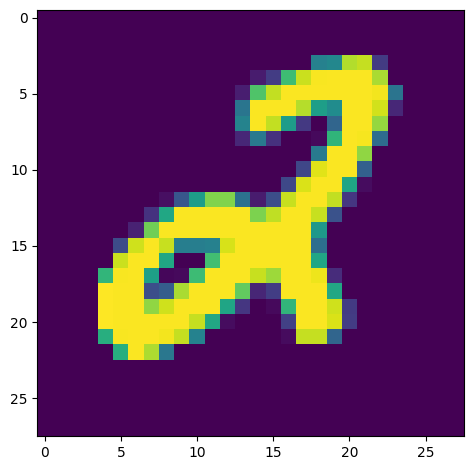

=== 7 ===
............................
............................
............................
............................
............................
............................
......................**....
.............*......****....
............***********.....
...........************.....
..........****....****......
.........****....****.......
.........***.....***........
........***.....***.........
.......***.....***..........
......***.....***...........
......**......***...........
.............***............
............***.............
............**..............
..........***...............
..........***...............
.........***................
........***.................
.......***..................
.......***..................
............................
............................



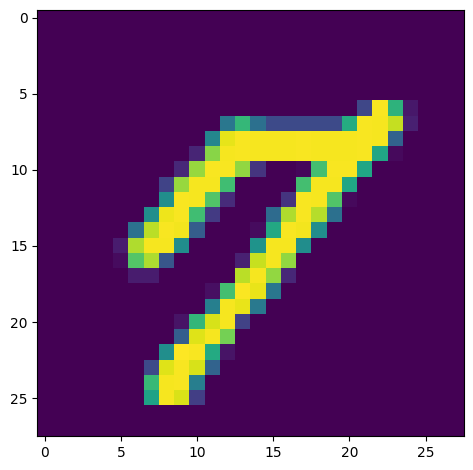

In [104]:
for batch in mnist_train_dataloader:
    inputs, labels = batch
    print(b)
    print(inputs.shape, labels.shape)
    for example, l in zip(inputs, labels):
        print(f'=== {int(l)} ===')
        for h in range(28):
            for w in range(28):
                print('*' if example[0][h][w] > 0.5 else '.', end='')
            print()
        print()
        plt.figure()
        plt.imshow(example[0])
        plt.tight_layout()
        plt.show()
    break

## Module

In [105]:
# only constraint is first layer input must be 28*28 and last layer must be 10

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 128), # we choose 128 hidden units
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
            nn.Softmax(dim=1),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [106]:
net = NeuralNetwork()
print(net)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
    (5): Softmax(dim=1)
  )
)


In [107]:
for b in mnist_train_dataloader:
    inputs, labels = b
    pred = net(inputs)
    print("Output:", pred)
    print("Predictions:", torch.argmax(pred, dim=1))
    print("Actual:", labels)
    print("Loss:", F.cross_entropy(pred, labels))
    break

Output: tensor([[0.1079, 0.0933, 0.1085, 0.0952, 0.1010, 0.1061, 0.1068, 0.0897, 0.0996,
         0.0919],
        [0.1076, 0.0950, 0.1049, 0.1019, 0.0981, 0.1024, 0.1110, 0.0880, 0.1041,
         0.0870]], grad_fn=<SoftmaxBackward0>)
Predictions: tensor([2, 6])
Actual: tensor([8, 9])
Loss: tensor(2.3093, grad_fn=<NllLossBackward0>)


## Metrics

In [108]:
import torchmetrics

In [109]:
# initialize metric
metric = torchmetrics.classification.Accuracy(task="multiclass", num_classes=5)

In [110]:
# Resetting internal state such that metric ready for new data
# reset between epochs
metric.reset()

In [111]:
n_batches = 10
for i in range(n_batches):
    # simulate a classification problem
    preds = torch.randn(10, 5).softmax(dim=-1)
    target = torch.randint(5, (10,))

    # metric on current batch
    acc = metric(preds, target) # has metric accumulate counts but only returns current value
    print("Predictions:", torch.argmax(preds, dim=1))
    print("Targets:", target)
    print(f"Accuracy on batch {i}: {acc}\n")

Predictions: tensor([0, 0, 0, 3, 1, 0, 4, 4, 3, 2])
Targets: tensor([4, 1, 2, 3, 4, 2, 0, 4, 0, 0])
Accuracy on batch 0: 0.20000000298023224

Predictions: tensor([2, 4, 3, 0, 3, 3, 4, 0, 0, 0])
Targets: tensor([1, 4, 1, 0, 2, 0, 0, 2, 3, 4])
Accuracy on batch 1: 0.20000000298023224

Predictions: tensor([2, 4, 0, 1, 1, 3, 2, 0, 2, 3])
Targets: tensor([0, 3, 0, 2, 1, 1, 2, 2, 0, 4])
Accuracy on batch 2: 0.30000001192092896

Predictions: tensor([1, 2, 3, 3, 2, 4, 3, 0, 2, 4])
Targets: tensor([0, 2, 1, 0, 4, 3, 4, 3, 2, 3])
Accuracy on batch 3: 0.20000000298023224

Predictions: tensor([3, 4, 3, 2, 1, 3, 3, 0, 2, 1])
Targets: tensor([1, 1, 1, 3, 3, 3, 4, 2, 2, 3])
Accuracy on batch 4: 0.20000000298023224

Predictions: tensor([2, 4, 0, 0, 0, 2, 0, 1, 2, 1])
Targets: tensor([1, 3, 2, 1, 2, 4, 3, 2, 4, 2])
Accuracy on batch 5: 0.0

Predictions: tensor([1, 3, 4, 3, 3, 3, 0, 2, 2, 4])
Targets: tensor([2, 1, 3, 0, 0, 1, 1, 0, 0, 1])
Accuracy on batch 6: 0.0

Predictions: tensor([3, 4, 3, 0, 1, 4,

In [112]:
# metric on all batches using custom accumulation
acc = metric.compute() # overall correct/total
print(f"Accuracy on all data: {acc}")

Accuracy on all data: 0.20000000298023224


## Application with Fabric

In [130]:
import lightning as L
from torch import optim
from torchmetrics import MeanMetric
from pathlib import Path
from torchmetrics.classification import Accuracy

In [113]:
# MLP model with two hidden layers
class MLP(nn.Module):
    def __init__(self, input_dim: int = 28 * 28, h: int = 128, num_classes: int = 10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h), nn.ReLU(),
            nn.Linear(h, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() > 2:
            x = x.view(x.size(0), -1)
        return self.net(x)

In [116]:
# CPU by default
L.seed_everything(42)
fabric = L.Fabric(accelerator="cpu", devices=1)

Seed set to 42


In [ ]:
# Data
BATCH_SIZE = 128

transform = transforms.ToTensor()
mnist_full = torchvision.datasets.MNIST("./data", train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST("./data", train=False, download=True, transform=transform)

In [ ]:
# quick train/val split
val_size = 10_000
train_size = len(mnist_full) - val_size
print("Train size", train_size)
train_set, val_set = random_split(mnist_full, [train_size, val_size])

50000


In [ ]:
# num_workers need to be 0 on Mac
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

train_loader, val_loader, test_loader = fabric.setup_dataloaders(train_loader, val_loader, test_loader)

In [134]:
# Model, loss, metric iniitalizer

# Model & Optimizer
model = MLP()
optimizer = optim.Adam(model.parameters(), lr=1e-3)  # fixed LR to reduce CLI noise
model, optimizer = fabric.setup(model, optimizer)

# Metrics for training display
train_loss_metric = fabric.setup_module(MeanMetric())


In [135]:
# Training Loop
NUM_EPOCHS = 5
best_acc = -1.0
ckpt_path = Path("checkpoints/best.pt")
ckpt_path.parent.mkdir(parents=True, exist_ok=True)

In [136]:
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss_metric.reset()

    for step, (xs, ys) in enumerate(train_loader, start=1):
        preds = model(xs)
        loss = F.cross_entropy(preds, ys)

        optimizer.zero_grad(set_to_none=True)
        fabric.backward(loss)
        optimizer.step()

        train_loss_metric.update(loss.detach())
        if step % 100 == 0:
            fabric.print(f"epoch {epoch:02d} step {step:04d} | loss {float(train_loss_metric.compute()):.4f}")

    # Validation
    model.eval()
    loss_metric = fabric.setup_module(MeanMetric())
    acc_metric = fabric.setup_module(Accuracy(task="multiclass", num_classes=10))

    for x, y in val_loader:
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        loss_metric.update(loss.detach())
        acc_metric.update(logits, y)
    val_acc = float(acc_metric.compute())
    fabric.print(f"epoch {epoch:02d} | val_loss {float(loss_metric.compute()):.4f} | val_acc {val_acc*100:.2f}%")

    # Save best model (by validation accuracy)
    if val_acc > best_acc:
        best_acc = val_acc
        fabric.save(ckpt_path, {"model": model.state_dict()})
        fabric.print(f"Saved new best model to {ckpt_path} (val_acc={val_acc*100:.2f}%)")

epoch 01 step 0100 | loss 0.8683
epoch 01 step 0200 | loss 0.6094
epoch 01 step 0300 | loss 0.5056
epoch 01 | val_loss 0.2586 | val_acc 92.48%
Saved new best model to checkpoints/best.pt (val_acc=92.48%)
epoch 02 step 0100 | loss 0.2382
epoch 02 step 0200 | loss 0.2264
epoch 02 step 0300 | loss 0.2181
epoch 02 | val_loss 0.1994 | val_acc 94.17%
Saved new best model to checkpoints/best.pt (val_acc=94.17%)
epoch 03 step 0100 | loss 0.1602
epoch 03 step 0200 | loss 0.1584
epoch 03 step 0300 | loss 0.1559
epoch 03 | val_loss 0.1608 | val_acc 95.24%
Saved new best model to checkpoints/best.pt (val_acc=95.24%)
epoch 04 step 0100 | loss 0.1292
epoch 04 step 0200 | loss 0.1265
epoch 04 step 0300 | loss 0.1244
epoch 04 | val_loss 0.1427 | val_acc 95.74%
Saved new best model to checkpoints/best.pt (val_acc=95.74%)
epoch 05 step 0100 | loss 0.1051
epoch 05 step 0200 | loss 0.1015
epoch 05 step 0300 | loss 0.0991
epoch 05 | val_loss 0.1200 | val_acc 96.35%
Saved new best model to checkpoints/best.

In [137]:
# load checkpoint and testing

# Create the model to simulate a deployment scenario.
model = MLP()

# Load checkpoint
if ckpt_path.exists():
    ckpt = fabric.load(ckpt_path)
    model.load_state_dict(ckpt["model"])
    fabric.print(f"Loaded best model from {ckpt_path}")

# Test
model.eval()
loss_metric = fabric.setup_module(MeanMetric())
acc_metric = fabric.setup_module(Accuracy(task="multiclass", num_classes=10))

for x, y in test_loader:
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    loss_metric.update(loss.detach())
    acc_metric.update(logits, y)
test_acc = float(acc_metric.compute())

fabric.print("=" * 60)
fabric.print(f"Test | loss {float(loss_metric.compute()):.4f} | acc {test_acc*100:.2f}%")

Loaded best model from checkpoints/best.pt
Test | loss 0.1035 | acc 96.84%
